<a href="https://colab.research.google.com/github/nevesmarcos42/HeatIA-Recife/blob/main/HeatIA_Recife.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***HeatAI Recife*** : Combina mapas de calor (heatmaps) e inteligência artificial (AI).

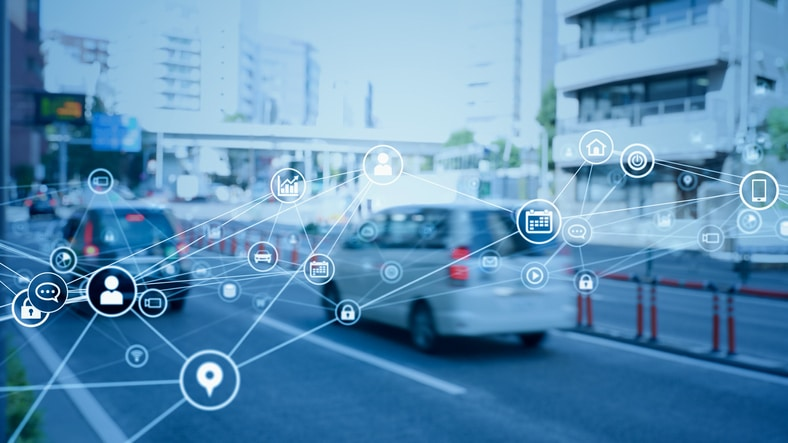



> Tratamento dos Dados


In [ ]:
import pandas as pd

# Carregar dados
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/HeatAI Recife/acidentes2024.csv", on_bad_lines='skip', delimiter=';')

# Visualizar as primeiras linhas
print(df.head())

  Protocolo        data      hora    natureza    situacao         bairro  \
0  292972,0  2024-01-01  06:05:00  COM VÍTIMA  FINALIZADA  VASCO DA GAMA   
1  292973,0  2024-01-01  09:14:00  COM VÍTIMA  FINALIZADA  VASCO DA GAMA   
2  292974,0  2024-01-01  10:31:00  COM VÍTIMA  FINALIZADA  VASCO DA GAMA   
3  292980,0  2024-01-01  04:11:00  COM VÍTIMA  FINALIZADA         ARRUDA   
4  292985,0  2024-01-01  06:53:00  COM VÍTIMA  FINALIZADA     BOA VIAGEM   

                            endereco numero  \
0  AV NORTE MIGUEL ARRAES DE ALENCAR    NaN   
1                  RUA VASCO DA GAMA   1353   
2             RUA ALTO TREZE DE MAIO    290   
3        AV PROFESSOR JOSE DOS ANJOS    NaN   
4              AV CONSELHEIRO AGUIAR   1672   

           detalhe_endereco_acidente  \
0                                NaN   
1                                NaN   
2                                NaN   
3  AV NORTE MIGUEL ARRAES DE ALENCAR   
4              RUA PADRE CARAPUCEIRO   

                   





```
# Transformação dos Dados
```




In [ ]:

# Selecionar colunas relevantes e criar uma cópia para evitar conflitos
colunas_importantes = ['data', 'bairro', 'tipo', 'vitimas', 'vitimasfatais']
dados_selecionados = df[colunas_importantes].copy()

# Substituir vírgulas por pontos nas colunas numéricas e converter para float
dados_selecionados['vitimas'] = dados_selecionados['vitimas'].str.replace(',', '.').astype(float)
dados_selecionados['vitimasfatais'] = dados_selecionados['vitimasfatais'].str.replace(',', '.').astype(float)

# Tratar valores ausentes (sem uso de inplace=True)
dados_selecionados['bairro'] = dados_selecionados['bairro'].fillna('Desconhecido')
dados_selecionados['tipo'] = dados_selecionados['tipo'].fillna('Desconhecido')
dados_selecionados['vitimas'] = dados_selecionados['vitimas'].fillna(dados_selecionados['vitimas'].median())
dados_selecionados['vitimasfatais'] = dados_selecionados['vitimasfatais'].fillna(dados_selecionados['vitimasfatais'].median())

# Visualizar os dados tratados
print(dados_selecionados.head())


         data         bairro             tipo  vitimas  vitimasfatais
0  2024-01-01  VASCO DA GAMA  COLISÃO LATERAL      1.0            0.0
1  2024-01-01  VASCO DA GAMA          COLISÃO      1.0            0.0
2  2024-01-01  VASCO DA GAMA          COLISÃO      1.0            0.0
3  2024-01-01         ARRUDA          COLISÃO      1.0            0.0
4  2024-01-01     BOA VIAGEM          COLISÃO      1.0            0.0






```
# Analise Exploratória (EDA)
```





In [ ]:
# Estatísticas descritivas
print(dados_selecionados.describe())

           vitimas  vitimasfatais
count  5315.000000    5315.000000
mean      0.947695       0.007526
std       0.439715       0.116157
min       0.000000       0.000000
25%       1.000000       0.000000
50%       1.000000       0.000000
75%       1.000000       0.000000
max       4.000000       6.000000


In [ ]:
print("Contagem de acidentes por bairro\n")
print(dados_selecionados['bairro'].value_counts())

print("\nContagem por tipo de acidente\n")
print(dados_selecionados['tipo'].value_counts())

Contagem de acidentes por bairro

bairro
BOA VIAGEM              549
IMBIRIBEIRA             305
SANTO AMARO             296
IBURA                   197
AFOGADOS                192
                       ... 
ALTO SANTA TERESINHA      4
BREJO DE BEBERIBE         3
SOLEDADE                  2
CACOTE                    2
HIPODROMO                 2
Name: count, Length: 94, dtype: int64

Contagem por tipo de acidente

tipo
COLISÃO                    2799
COLISÃO LATERAL            1260
COLISÃO TRASEIRA            389
COLISÃO FRONTAL             264
ATROPELAMENTO DE PESSOA     181
CHOQUE                      120
COLISÃO COM CICLISTA         91
QUEDA                        77
COLISÃO TRANSVERSAL          62
Desconhecido                 30
CAPOTAMENTO                  20
ENGAVETAMENTO                12
TOMBAMENTO                    7
ATROPELAMENTO DE ANIMAL       3
Name: count, dtype: int64





```
# Visualização com Gráfico
```



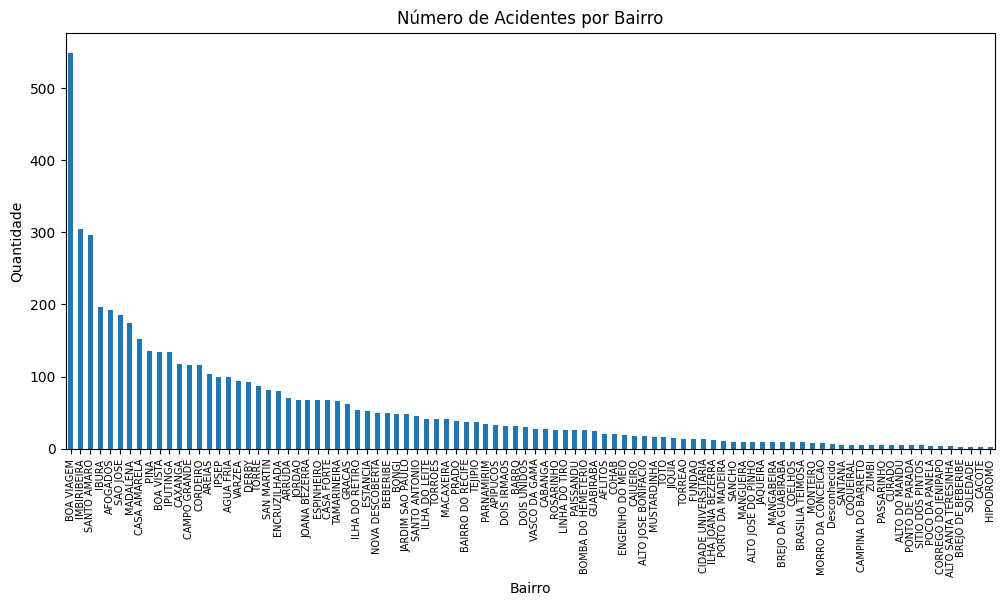

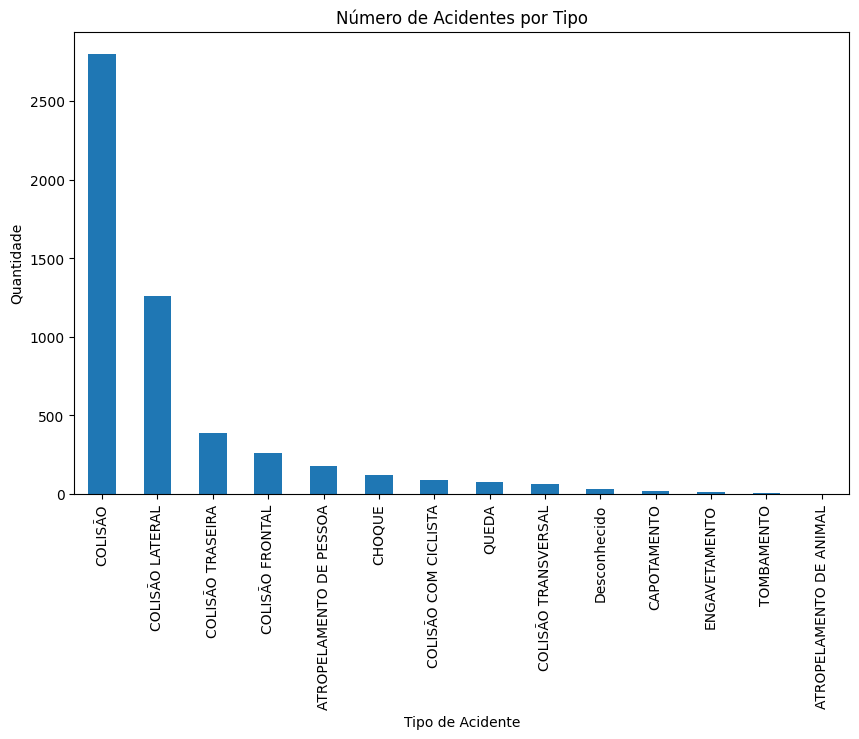

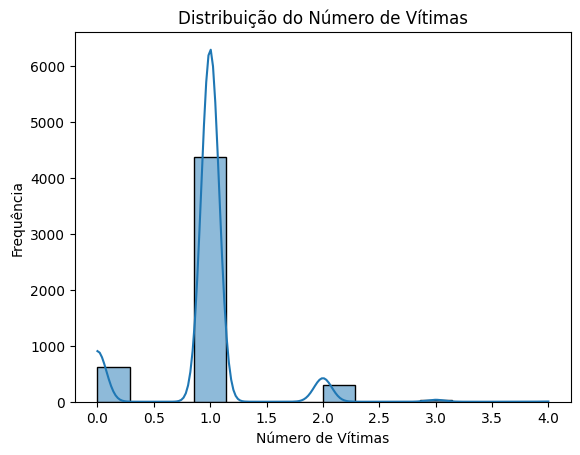

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de barras - Acidentes por bairro
dados_selecionados['bairro'].value_counts().plot(kind='bar', figsize=(10, 6))
plt.title("Número de Acidentes por Bairro")
plt.xlabel("Bairro")
plt.ylabel("Quantidade")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout(pad=0.5)  # Ajustar o espaçamento geral
plt.show()

# Gráfico de barras - Tipos de acidentes
dados_selecionados['tipo'].value_counts().plot(kind='bar', figsize=(10, 6))
plt.title("Número de Acidentes por Tipo")
plt.xlabel("Tipo de Acidente")
plt.ylabel("Quantidade")
plt.show()

# Histograma - Distribuição de vítimas
sns.histplot(dados_selecionados['vitimas'], kde=True)
plt.title("Distribuição do Número de Vítimas")
plt.xlabel("Número de Vítimas")
plt.ylabel("Frequência")
plt.show()

In [ ]:
# Otem as Coordenadas Geográficas (Latitude e Longitude) de Bairros em Recife
from geopy.geocoders import Nominatim
import pandas as pd
import time

# Inicializar o geolocalizador com um tempo limite maior (10 segundos)
geolocator = Nominatim(user_agent="analise_acidentes_recife", timeout=10)

# Função para obter coordenadas com tratamento de exceções
def obter_coordenadas(bairro):
    try:
        location = geolocator.geocode(f"{bairro}, Recife, Brasil")
        if location:
            return location.latitude, location.longitude
        else:
            return None, None
    except:
        return None, None

# Geocodificar apenas bairros únicos para evitar consultas repetitivas
bairros_unicos = dados_selecionados['bairro'].unique()
coordenadas = {}

for bairro in bairros_unicos:
    try:
        location = geolocator.geocode(f"{bairro}, Recife, Brasil")
        if location:
            coordenadas[bairro] = (location.latitude, location.longitude)
        else:
            coordenadas[bairro] = (None, None)
    except:
        coordenadas[bairro] = (None, None)
    time.sleep(1)  # Pausar 1 segundo entre as requisições

# Mapear as coordenadas de volta para o DataFrame
dados_selecionados['latitude'] = dados_selecionados['bairro'].map(lambda x: coordenadas[x][0])
dados_selecionados['longitude'] = dados_selecionados['bairro'].map(lambda x: coordenadas[x][1])

# Filtrar dados com coordenadas válidas
dados_com_coordenadas = dados_selecionados.dropna(subset=['latitude', 'longitude'])

# Visualizar os resultados
print(dados_com_coordenadas[['bairro', 'latitude', 'longitude']].head())

          bairro  latitude  longitude
0  VASCO DA GAMA -8.011774 -34.919054
1  VASCO DA GAMA -8.011774 -34.919054
2  VASCO DA GAMA -8.011774 -34.919054
3         ARRUDA -8.025082 -34.891323
4     BOA VIAGEM -8.123503 -34.903396






```
# Mapa de Calor dos Bairros de Recife
```





In [ ]:
import folium
from folium.plugins import HeatMap
from IPython.display import IFrame

# Criar o mapa base centrado em Recife
mapa = folium.Map(location=[-8.0476, -34.8770], zoom_start=12)

# Adicionar os dados ao HeatMap
heat_data = [[row['latitude'], row['longitude']] for index, row in dados_com_coordenadas.iterrows()]
HeatMap(heat_data).add_to(mapa)

# Salva e visualiza no notebook
mapa.save("/content/drive/MyDrive/Colab Notebooks/HeatAI Recife/mapa_acidentes_recife.html")
IFrame("/content/drive/MyDrive/Colab Notebooks/HeatAI Recife/mapa_acidentes_recife.html", width=700, height=500)


print("Mapa de calor criado e salvo como 'mapa_acidentes_recife.html'.")

# Renderizar diretamente no notebook
mapa._repr_html_()

mapa  # Exibe o mapa diretamente no notebook

Mapa de calor criado e salvo como 'mapa_acidentes_recife.html'.


In [ ]:
# Codifica Variáveis Categóricas
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
dados_selecionados['local_cod'] = le.fit_transform(dados_selecionados['bairro'])
dados_selecionados['tipo_acidente_cod'] = le.fit_transform(dados_selecionados['tipo'])

# Converte a coluna 'data' para o formato datetime
dados_selecionados['data'] = pd.to_datetime(dados_selecionados['data'], errors='coerce')

# Verifica e tratar valores inválidos após a conversão
dados_selecionados['data'] = dados_selecionados['data'].fillna(pd.Timestamp('1970-01-01'))

# Agora extrai as características temporais
dados_selecionados['ano'] = dados_selecionados['data'].dt.year
dados_selecionados['mes'] = dados_selecionados['data'].dt.month
dados_selecionados['dia'] = dados_selecionados['data'].dt.day


# Entradas (X) e saídas (y)
X = dados_selecionados[['local_cod', 'tipo_acidente_cod', 'ano', 'mes', 'dia', 'vitimas']]
y_tipo = dados_selecionados['tipo_acidente_cod']  # Saída para classificação (tipo de acidente)
y_gravidade = dados_selecionados['vitimasfatais']  # Saída para regressão (gravidade)

In [ ]:
# Visualizar os dados tratados
dados_selecionados.head()

,data,bairro,tipo,vitimas,vitimasfatais,latitude,longitude,local_cod,tipo_acidente_cod,ano,mes,dia
0,2024-01-01,VASCO DA GAMA,COLISÃO LATERAL,1.0,0.0,-8.011774,-34.919054,92,7,2024,1,1
1,2024-01-01,VASCO DA GAMA,COLISÃO,1.0,0.0,-8.011774,-34.919054,92,4,2024,1,1
2,2024-01-01,VASCO DA GAMA,COLISÃO,1.0,0.0,-8.011774,-34.919054,92,4,2024,1,1
3,2024-01-01,ARRUDA,COLISÃO,1.0,0.0,-8.025082,-34.891323,9,4,2024,1,1
4,2024-01-01,BOA VIAGEM,COLISÃO,1.0,0.0,-8.123503,-34.903396,13,4,2024,1,1


In [ ]:
# Remover valores nulos e anômalos
dados_selecionados = dados_selecionados.dropna()
features = ["local_cod", "tipo_acidente_cod", "ano", "mes", "dia", "latitude", "longitude"]
target = "vitimas"

X = dados_selecionados[features].values
y = dados_selecionados[target].values.astype(np.float32).reshape(-1, 1)

# Normalizar dados numéricos
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Criar nova feature: densidade de acidentes por região
dados_selecionados["densidade_acidentes"] = dados_selecionados.groupby("local_cod")["vitimas"].transform("sum")
X = np.hstack((X, dados_selecionados["densidade_acidentes"].values.reshape(-1, 1)))

In [ ]:
# Dividir dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Converter para tensores PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)



> Rede Neural



In [ ]:
# Criar modelo de rede neural ajustado
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(len(features) + 1, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 16)
        self.fc5 = nn.Linear(16, 1)
        self.swish = nn.SiLU()
        self.dropout = nn.Dropout(0.15)

    def forward(self, x):
        x = self.swish(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.swish(self.bn2(self.fc2(x)))
        x = self.swish(self.fc3(x))
        x = self.swish(self.fc4(x))
        x = self.fc5(x)
        return x

In [ ]:
# Instanciar modelo
model = NeuralNetwork()

# Inicializar pesos corretamente
for layer in model.children():
    if isinstance(layer, nn.Linear):
        torch.nn.init.xavier_normal_(layer.weight)
        if layer.bias is not None:
            torch.nn.init.zeros_(layer.bias)

# Definir função de perda e otimizador ajustado
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=0.00005)

In [ ]:
# Treinar modelo
epochs = 350
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)

    if torch.isnan(outputs).any():
        print(f"Erro: NaN detectado na época {epoch}")
        break

    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 1.437277913093567
Epoch 10, Loss: 1.076186180114746
Epoch 20, Loss: 0.8962303400039673
Epoch 30, Loss: 0.7637724876403809
Epoch 40, Loss: 0.6604722738265991
Epoch 50, Loss: 0.5693270564079285
Epoch 60, Loss: 0.49157020449638367
Epoch 70, Loss: 0.4188120365142822
Epoch 80, Loss: 0.3621341586112976
Epoch 90, Loss: 0.31567874550819397
Epoch 100, Loss: 0.2786760628223419
Epoch 110, Loss: 0.2518056333065033
Epoch 120, Loss: 0.23351220786571503
Epoch 130, Loss: 0.21875400841236115
Epoch 140, Loss: 0.21070076525211334
Epoch 150, Loss: 0.20345564186573029
Epoch 160, Loss: 0.20087465643882751
Epoch 170, Loss: 0.19933468103408813
Epoch 180, Loss: 0.19776557385921478
Epoch 190, Loss: 0.1967887282371521
Epoch 200, Loss: 0.19660228490829468
Epoch 210, Loss: 0.1956532746553421
Epoch 220, Loss: 0.19594192504882812
Epoch 230, Loss: 0.19515056908130646
Epoch 240, Loss: 0.19322393834590912
Epoch 250, Loss: 0.19377407431602478
Epoch 260, Loss: 0.19367046654224396
Epoch 270, Loss: 0.1920188

In [ ]:
# Avaliação no conjunto de teste
model.eval()
test_outputs = model(X_test_tensor)
test_loss = criterion(test_outputs, y_test_tensor)
print(f"Loss final no conjunto de teste: {test_loss.item()}")

Loss final no conjunto de teste: 0.19710320234298706


In [ ]:
# ----------- 🔮 PREVISÃO PARA 2025 -----------

# Criar dataset futuro baseado nos padrões atuais
dados_2025 = dados_selecionados.copy()
dados_2025["ano"] = 2025

# Normalizar o novo conjunto de dados
X_2025 = dados_2025[features].values
X_2025 = scaler.transform(X_2025)
X_2025 = np.hstack((X_2025, dados_2025["densidade_acidentes"].values.reshape(-1, 1)))

# Converter para tensor
X_2025_tensor = torch.tensor(X_2025, dtype=torch.float32)

# Fazer previsões para 2025
predicoes_2025 = model(X_2025_tensor).detach().numpy()

# Adicionar previsões ao dataframe
dados_2025["pred_vitimas_2025"] = predicoes_2025

In [ ]:
# ----------- 🗺️ MAPA DE CALOR DOS ACIDENTES -----------
print("\n🌍 **Mapa de calor gerado apresenta a previsão para as localidade com altos indices de acidentes em 2025.")

# Criar um mapa centrado em Recife
mapa = folium.Map(location=[-8.05, -34.90], zoom_start=12)

# Adicionar pontos de calor
heat_data = dados_2025[['latitude', 'longitude', 'pred_vitimas_2025']].values.tolist()
HeatMap(heat_data).add_to(mapa)

# Exibir mapa diretamente no Colab
display(mapa)


🌍 **Mapa de calor gerado apresenta a previsão para as localidade com altos indices de acidentes em 2025.


# Conclusão

Após uma jornada de refinamento e ajustes precisos, conseguimos desenvolver um modelo preditivo robusto para análise de risco de acidentes em Recife. Com o uso de redes neurais profundas, dados geográficos, e a criação de um mapa de calor interativo, agora temos uma ferramenta capaz de identificar padrões e prever locais de maior risco em 2025.
O resultado desse trabalho não se limita a números e estatísticas. Ele representa uma oportunidade real de intervenção para reduzir acidentes e aumentar a segurança nas vias. A combinação entre ciência de dados e aprendizado de máquina nos permite não apenas entender os eventos passados, mas agir preventivamente no futuro.
Com esse modelo, podemos:
- Identificar áreas críticas e sugerir melhorias na infraestrutura urbana.
- Ajudar órgãos de trânsito na tomada de decisões estratégicas.
- Educar a população sobre os pontos de maior risco e incentivar práticas mais seguras.

Este projeto prova que dados bem estruturados e tecnologia podem salvar vidas. Mais do que prever números, conseguimos transformar informações em soluções reais para o trânsito e a mobilidade urbana.
Agora, o próximo passo é expandir a análise, testar novas variáveis e garantir que essa ferramenta continue evoluindo para atender às necessidades da sociedade e dos gestores públicos.
Este não é o fim, mas o começo de um futuro mais seguro e inteligente para as ruas de Recife! 🚀📊

---

